📂 Please upload your CSV file...


Saving Sample - Superstore.csv to Sample - Superstore (2).csv

📂 Loading data...
✅ Data loaded! Preview:
   Order Date         Category     Sales    Profit
0   11/8/2016        Furniture  261.9600   41.9136
1   11/8/2016        Furniture  731.9400  219.5820
2   6/12/2016  Office Supplies   14.6200    6.8714
3  10/11/2015        Furniture  957.5775 -383.0310
4  10/11/2015  Office Supplies   22.3680    2.5164

📊 Creating chart...


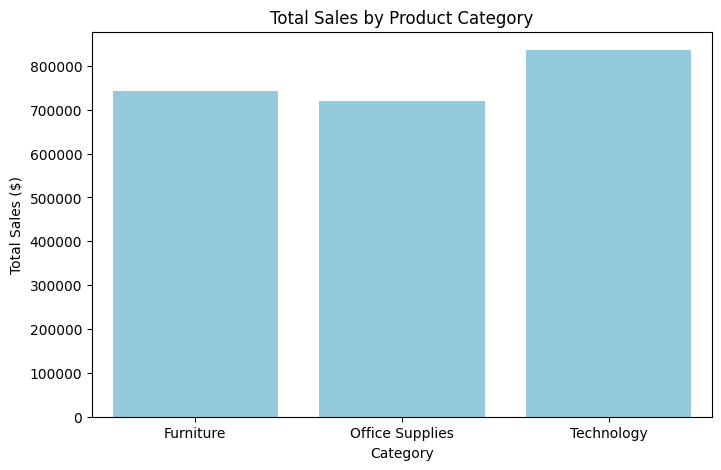


🎉 Done!


In [4]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("📂 Please upload your CSV file...")
uploaded = files.upload()

# Load the data with the correct encoding to fix the error
print("\n📂 Loading data...")
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Show first 5 rows
print("✅ Data loaded! Preview:")
print(df[['Order Date', 'Category', 'Sales', 'Profit']].head())

# Create chart
print("\n📊 Creating chart...")
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Category', y='Sales', estimator=sum, errorbar=None, color='skyblue')
plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.show()

print("\n🎉 Done!")

📈 Chart 2: Monthly Sales Trend


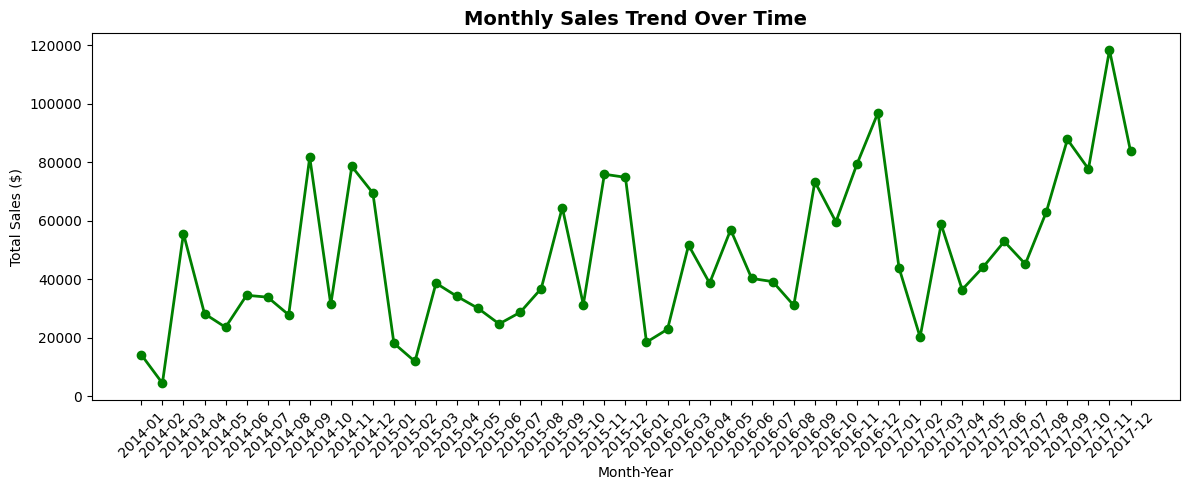


📈 Chart 3: Profit by Region


/tmp/ipykernel_1345/1598108856.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_profit, x='Region', y='Profit', palette='viridis')


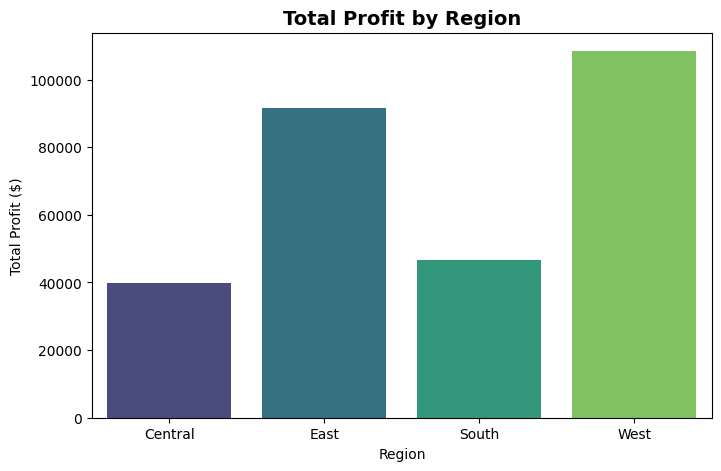


📈 Chart 4: Top 10 Products by Profit


/tmp/ipykernel_1345/1598108856.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Profit', y='Product Name', palette='coolwarm')


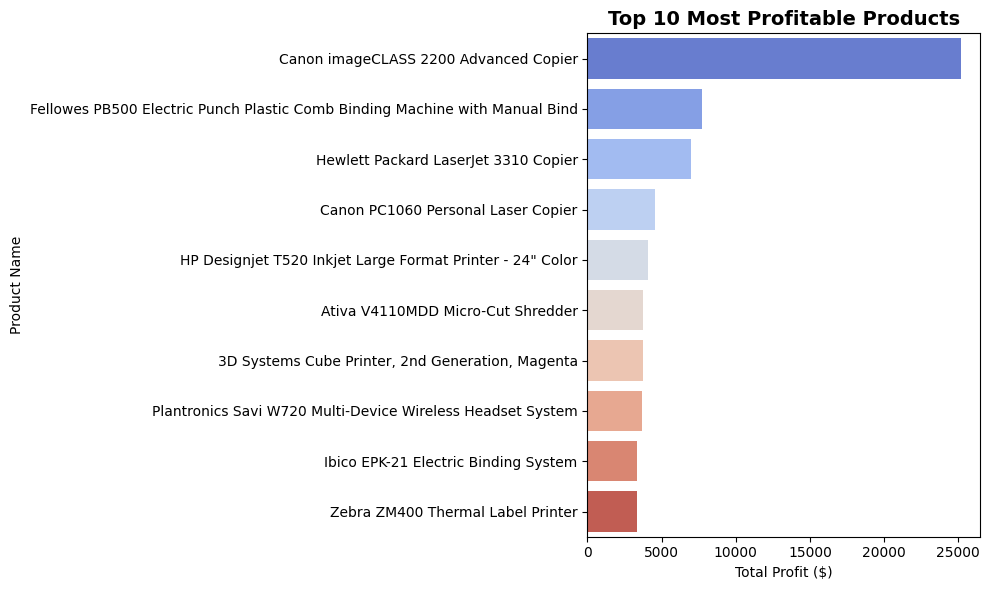


✅ All charts generated successfully!


In [7]:
# Chart 2: Monthly Sales Trend
print("📈 Chart 2: Monthly Sales Trend")
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month-Year'] = df['Order Date'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('Month-Year')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Month-Year'], monthly_sales['Sales'], marker='o', color='green', linewidth=2)
plt.title('Monthly Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 3: Profit by Region
print("\n📈 Chart 3: Profit by Region")
plt.figure(figsize=(8, 5))
region_profit = df.groupby('Region')['Profit'].sum().reset_index()
sns.barplot(data=region_profit, x='Region', y='Profit', palette='viridis')
plt.title('Total Profit by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.show()

# Chart 4: Top 10 Products by Profit
print("\n📈 Chart 4: Top 10 Products by Profit")
top_products = df.groupby('Product Name')['Profit'].sum().reset_index().nlargest(10, 'Profit')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='Profit', y='Product Name', palette='coolwarm')
plt.title('Top 10 Most Profitable Products', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

print("\n✅ All charts generated successfully!")